# Differential CpG methylation in promoter regions

This notebook identifies differentially CpG methylated regions between MeD-seq samples.

## Input

- CpG methylation labels per region, available from GEO (GSE304236_CpG.regions.txt)
- Tables S6 and S7, generated in notebook 15
- Scanpy object generated in notebook 6 (scRNA.h5ad)

## Output

- Figure 6e and f: Violin plots of scRNA-seq counts of genes with promotor DMRs
- Figure 6g, S10d, S10e: HNF4A, APOA1 and IHH
- Figure 5f. Promoter hypomethylation

## Packages

In [1]:
# General
from pathlib import Path
import numpy as np
import pandas as pd

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Statistics
import scipy
from scipy.stats import mannwhitneyu, median_abs_deviation
from statsmodels.stats.multitest import multipletests
from itertools import combinations

# scRNA-seq analysis
import warnings
warnings.simplefilter("ignore", category=(UserWarning, FutureWarning, DeprecationWarning))
import scanpy as sc
import pyucell as uc

# Plot settings
plt.rcParams.update({"figure.figsize": (10, 10), "svg.fonttype": "none", "font.family": "Arial"})
sc.set_figure_params(format="svg", dpi_save=300, figsize=(10,10))
sns.set_style("ticks")

# Hide warnings
import warnings
warnings.simplefilter("ignore", category=(UserWarning, FutureWarning, DeprecationWarning))

# Versions
sc.logging.print_versions()

-----
anndata     0.11.4
scanpy      1.10.3
-----
PIL                         10.4.0
anyio                       NA
argcomplete                 NA
arrow                       1.4.0
asttokens                   NA
attr                        25.4.0
attrs                       25.4.0
babel                       2.16.0
brotli                      1.2.0
certifi                     2026.02.25
cffi                        2.0.0
charset_normalizer          3.3.2
colorama                    0.4.6
comm                        0.2.3
cycler                      0.12.1
cython_runtime              NA
dateutil                    2.9.0.post0
debugpy                     1.8.17
decorator                   5.2.1
defusedxml                  0.7.1
exceptiongroup              1.2.2
executing                   2.2.1
fastjsonschema              NA
fqdn                        NA
h5py                        3.12.1
idna                        3.11
ipykernel                   6.26.0
ipywidgets                  8.1.

In [2]:
# Directories: update these paths as needed
input_dir = "../Input/GEO"   # folder where GEO data is stored
output_dir = "../Output"    # folder where output files will be saved
Path(output_dir).mkdir(parents=True, exist_ok=True)
sc.settings.figdir = output_dir

# Settings
labels = ["iPSC", "DE", "PGT"]              # custom labels
colors = ["#264653", "#E9C46A", "#E76F51"]  # colors to use
palette = dict(zip(labels, colors))         # palette for plots

comparisons = ["iPSC_DE", "DE_PGT"]
comparison_colors = [["#264653", "#E9C46A"], ["#E9C46A", "#E76F51"]] 

## Promoter DMRs

In [3]:
iPSC_DE = pd.read_csv(f"{output_dir}/SupplementalTable6.txt", sep="\t", index_col=0, header=0)
iPSC_DE = iPSC_DE[iPSC_DE["Region"] == "Promoter"]
display(iPSC_DE)

DE_PGT = pd.read_csv(f"{output_dir}/SupplementalTable7.txt", sep="\t", index_col=0, header=0)
DE_PGT = DE_PGT[DE_PGT["Region"] == "Promoter"]
display(DE_PGT)

de_dfs = [iPSC_DE, DE_PGT]
comparisons = [["iPSC", "DE"], ["DE", "PGT"]]

,baseMean,log2FoldChange,lfcSE,pvalue,padj,Category,-log10(adjusted P-value),LogBaseMean,C4neg-1,C4neg-2,...,DE-d1,DE-d2,DE-d3,PGT-c1,PGT-c2,PGT-c3,NrSites,GeneName,GeneID,Region
Promoter.ENSG00000232133,29.115828,2.660634,0.318468,5.181047e-18,1.627833e-14,DE,13.788390,1.464144,13,11,...,62,46,54,79,63,68,16,IMPDH1P10,ENSG00000232133,Promoter
Promoter.ENSG00000260281,20.600640,3.313010,0.434139,4.130425e-16,8.283623e-13,DE,12.081780,1.313902,0,1,...,33,31,39,20,4,64,166,ITFG1-AS1,ENSG00000260281,Promoter
Promoter.ENSG00000287040,44.097182,-1.946796,0.253390,4.387416e-15,6.782579e-12,iPSC,11.168605,1.644421,120,81,...,22,12,20,13,17,9,17,.,ENSG00000287040,Promoter
Promoter.ENSG00000255557,95.101841,1.044061,0.140046,4.737711e-14,5.958595e-11,DE,10.224856,1.978193,75,61,...,124,147,105,157,128,193,156,.,ENSG00000255557,Promoter
Promoter.ENSG00000029534,67.346010,1.443122,0.199249,2.239902e-13,2.340982e-10,DE,9.630602,1.828318,41,37,...,89,103,112,74,80,110,253,ANK1,ENSG00000029534,Promoter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Promoter.ENSG00000162069,359.756977,-0.273740,0.155028,9.025452e-03,4.983812e-02,iPSC,1.302438,2.556010,525,450,...,283,337,317,407,395,407,128,BICDL2,ENSG00000162069,Promoter
Promoter.ENSG00000180210,48.377365,-0.286905,0.170199,9.029437e-03,4.984528e-02,iPSC,1.302376,1.684651,60,62,...,39,37,35,41,44,45,17,F2,ENSG00000180210,Promoter
Promoter.ENSG00000130779,6.401692,1.045947,0.953142,9.028624e-03,4.984528e-02,DE,1.302376,0.806363,2,2,...,7,17,17,16,26,32,50,CLIP1,ENSG00000130779,Promoter
Promoter.ENSG00000112796,2.881050,1.043359,1.146791,9.041817e-03,4.989507e-02,DE,1.301942,0.459702,0,0,...,6,12,5,7,0,0,16,ENPP5,ENSG00000112796,Promoter


,baseMean,log2FoldChange,lfcSE,pvalue,padj,Category,-log10(adjusted P-value),LogBaseMean,C4neg-1,C4neg-2,...,DE-d1,DE-d2,DE-d3,PGT-c1,PGT-c2,PGT-c3,NrSites,GeneName,GeneID,Region
Promoter.ENSG00000148396,153.994005,-1.124359,0.181313,3.699266e-17,6.863619e-13,DE,12.163447,2.187507,514,196,...,171,143,193,99,82,89,15,SEC16A,ENSG00000148396,Promoter
Promoter.ENSG00000163501,206.955066,-1.487587,0.191524,8.603334e-17,1.064175e-12,DE,11.972987,2.315878,468,203,...,325,209,199,96,127,78,80,IHH,ENSG00000163501,Promoter
Promoter.ENSG00000173262,178.819052,0.921368,0.179263,4.994387e-14,2.316647e-10,PGT,9.635140,2.252416,244,96,...,106,144,108,303,346,263,49,SLC2A14,ENSG00000173262,Promoter
Promoter.ENSG00000229005,127.744204,-0.925977,0.203622,1.846819e-12,4.540120e-09,DE,8.342933,2.106345,320,206,...,147,132,135,71,64,101,31,HNF4A-AS1,ENSG00000229005,Promoter
Promoter.ENSG00000118137,38.539848,-1.856756,0.314806,5.375023e-11,6.649416e-08,DE,7.177216,1.585921,55,62,...,50,52,50,13,15,14,12,APOA1,ENSG00000118137,Promoter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Promoter.ENSG00000107404,580.065691,0.271786,0.127973,3.200886e-03,4.857022e-02,PGT,1.313630,2.763478,1225,553,...,519,494,341,819,712,734,143,DVL1,ENSG00000107404,Promoter
Promoter.ENSG00000244476,40.993229,-0.296115,0.224561,3.223804e-03,4.882813e-02,DE,1.311330,1.612723,74,52,...,39,62,64,28,29,26,39,ERVFRD-1,ENSG00000244476,Promoter
Promoter.ENSG00000103042,69.452149,0.314825,0.172014,3.258057e-03,4.921767e-02,PGT,1.307879,1.841692,89,39,...,62,50,57,104,78,110,26,SLC38A7,ENSG00000103042,Promoter
Promoter.ENSG00000226828,25.479643,-0.280163,0.233927,3.329545e-03,4.991426e-02,DE,1.301775,1.406210,13,13,...,29,36,22,10,17,22,134,LINC02774,ENSG00000226828,Promoter


## Figure 6e and f: Violin plots of scRNA-seq counts of genes with promotor DMRs

AnnData object with n_obs × n_vars = 1022 × 36693
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'Celltype', 'outlier'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts-DE', 'mean_counts-DE', 'log1p_mean_counts-DE', 'pct_dropout_by_counts-DE', 'total_counts-DE', 'log1p_total_counts-DE', 'n_cells_by_counts-PGT', 'mean_counts-PGT', 'log1p_mean_counts-PGT', 'pct_dropout_by_counts-PGT', 'total_counts-PGT', 'log1p_total_counts-PGT', 'n_cells_by_counts-iPSC', 'mean_counts-iPSC', 'log1p_mean_counts-iPSC', 'pct_dropout_by_counts-iPSC', 'total_counts-iPSC', 'log1p_total_counts-iPSC', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Celltype', 'Celltype_colors', 'hvg', 'log1p', 'neighbors', 'pca'
    obsm: 'Harmo

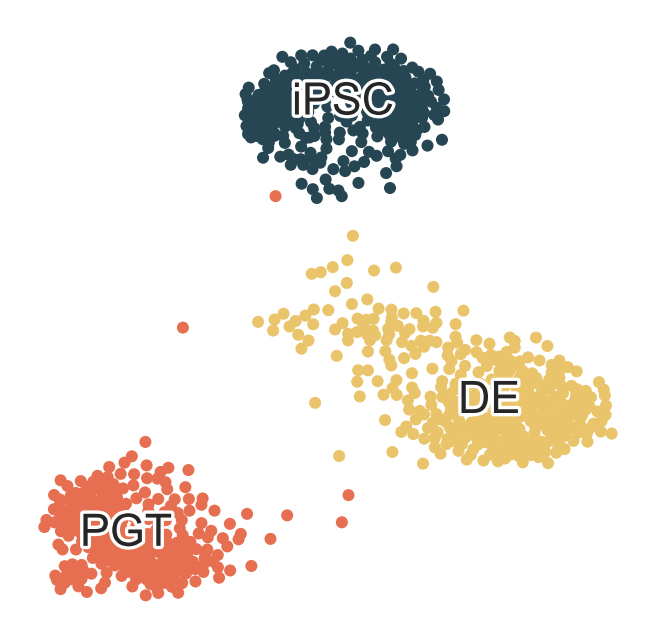

In [4]:
# Load scRNA-seq dataset
adata = sc.read_h5ad(f"{output_dir}/scRNA.h5ad")
print(adata)

with plt.rc_context({"figure.figsize": (5, 5)}):
    sc.pl.embedding(adata, basis="Harmony", frameon=False, color="Celltype", palette=palette, title="",
                    legend_loc="on data", legend_fontsize="x-large", legend_fontweight="normal", legend_fontoutline=3, show=True)

In [5]:
for i, de_df in enumerate(de_dfs):
    x, y = comparisons[i]

    for j, sign in enumerate([y, x]):
        sign_genes = de_df[de_df["Category"] == sign]["GeneName"]
        sign_genes = [gene for gene in sign_genes if gene in adata.var_names]
        sc.tl.score_genes(adata, sign_genes, score_name=f"{i}_{sign}")

In [6]:
def cliffs_delta(group1, group2):
    diff = np.expand_dims(group1, axis=1) - group2
    delta = np.sum(np.sign(diff)) / (len(group1) * len(group2))
    return delta

stats_results = {}

for i, de_df in enumerate(de_dfs):
    x, y = comparisons[i]
    
    for j, sign in enumerate([x, y]):
        plot_value = f"{i}_{sign}"

        left_values = adata[adata.obs["Celltype"] == x].obs[plot_value].values
        right_values = adata[adata.obs["Celltype"] == y].obs[plot_value].values
        
        stat, p_value = scipy.stats.mannwhitneyu(left_values, right_values, alternative="two-sided")
        eff_size = cliffs_delta(right_values, left_values)

        stats_results[f"{i}.{j}.{x}.{y}"] = [i, j, x, y, p_value, eff_size]

stats_df = pd.DataFrame.from_dict(stats_results, orient="index", columns=["Analysis", "Genelist", "X", "Y", "P-value", "Cliff d"])
stats_df["Adj P-value"] = multipletests(stats_df["P-value"], method="bonferroni")[1]
display(stats_df)

,Analysis,Genelist,X,Y,P-value,Cliff d,Adj P-value
0.0.iPSC.DE,0,0,iPSC,DE,2.762763e-23,-0.423124,1.105105e-22
0.1.iPSC.DE,0,1,iPSC,DE,2.351213e-33,-0.512217,9.404854e-33
1.0.DE.PGT,1,0,DE,PGT,1.343081e-42,0.624055,5.372326e-42
1.1.DE.PGT,1,1,DE,PGT,6.982815e-24,-0.459706,2.793126e-23


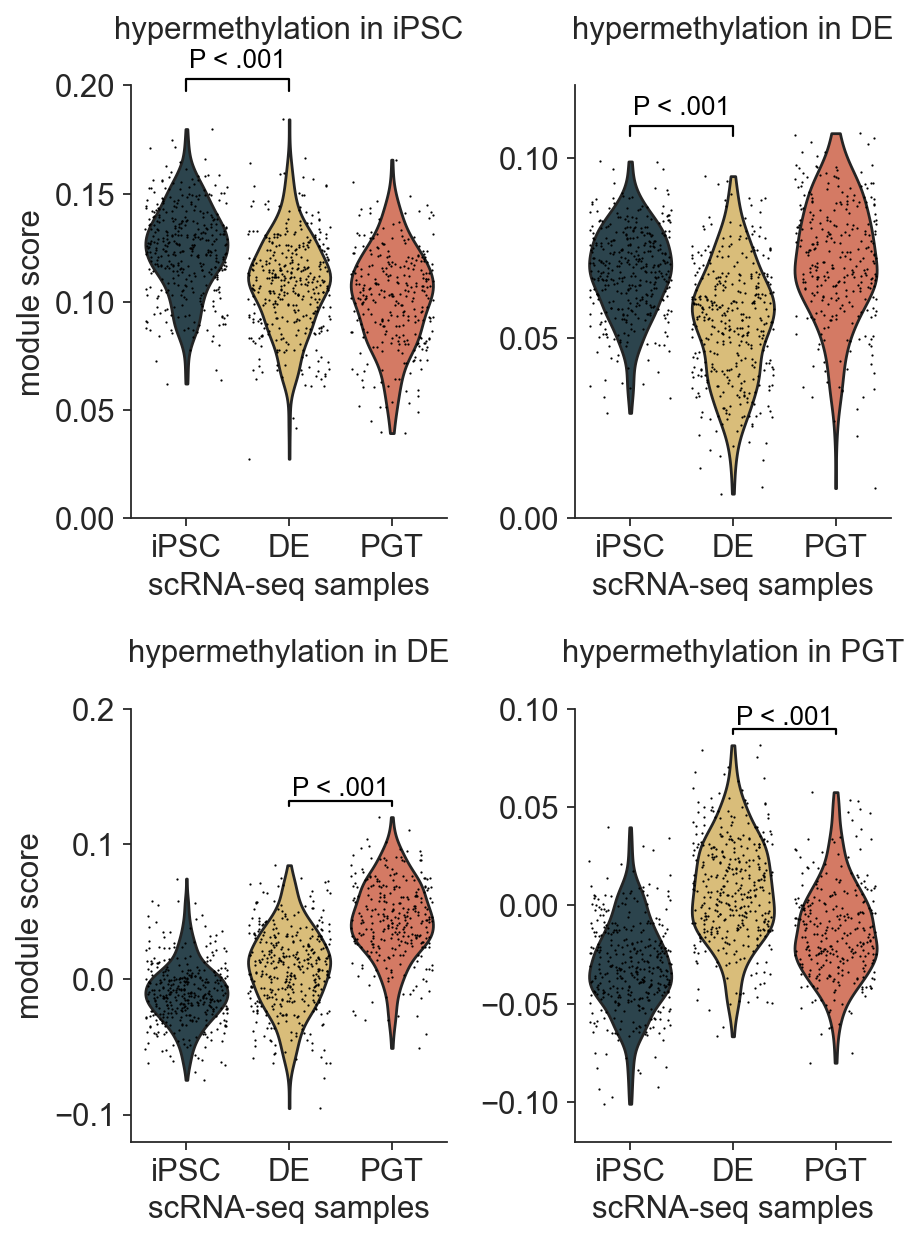

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(6, 8))

for i, de_df in enumerate(de_dfs):
    x, y = comparisons[i]
    
    for j, sign in enumerate([x, y]):
        plot_value = f"{i}_{sign}"
        
        # Plot UCell scores in violin
        sc.pl.violin(adata, plot_value, groupby="Celltype", jitter=0.4, show=False, ax=axs[i,j])
        axs[i,j].set(title=f"hypermethylation in {sign}\n", 
                     xlabel="scRNA-seq samples", ylabel="", ylim=(None, axs[i,j].get_ylim()[1]*1.1))

        ## Add p-values
        p_value = stats_df.loc[f"{i}.{j}.{x}.{y}", "Adj P-value"]
        d_value = stats_df.loc[f"{i}.{j}.{x}.{y}", "Cliff d"]
        #formatted_p = f"d = {d_value:.2f}, P < .001" if p_value < 0.001 else "n.s." if p_value >= 0.05 else f"P = {p_value:.3f}"
        formatted_p = f"P < .001" if p_value < 0.001 else "n.s." if p_value >= 0.05 else f"P = {p_value:.3f}"
        x1, x2 = [0, 1] if i == 0 else [1, 2]
        y_max = adata[adata.obs["Celltype"].isin([x, y])].obs[plot_value].max() * 1.1
        yh = adata[adata.obs["Celltype"].isin([x, y])].obs[plot_value].max() * 0.03
        axs[i,j].plot([x1, x1, x2, x2], [y_max-yh, y_max, y_max, y_max-yh], color="black", linewidth=1, clip_on=False)
        axs[i,j].text((x1+x2)/2, y_max+yh, formatted_p, ha="center", color="black", fontsize="small", rotation=0)

    axs[i, 0].set(ylabel=f"module score")

axs[0, 0].set(ylim=(0, 0.20))
axs[0, 1].set(ylim=(0, 0.12), yticks=(0, 0.05, 0.1))
axs[1, 0].set(ylim=(-0.12, 0.2))
axs[1, 1].set(ylim=(-0.12, 0.1))

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/Figure5f-g.svg", format="svg")
plt.show()

## Figure 6g, S10d, S10e: HNF4A, APOA1 and IHH

In [8]:
counts_gene = pd.read_csv("../NewGEOfiles/CpG_homer.txt", sep="\t", index_col=0)
counts_gene = counts_gene[counts_gene["NrSites"] > 10]

counts_promoter = counts_gene[counts_gene["Region"] == "Promoter"]
counts_promoter = counts_promoter.drop(["NrSites", "GeneName", "GeneID", "Region"], axis=1)
display(counts_promoter)

,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3,DE-c1,DE-c2,DE-c3,DE-d1,DE-d2,DE-d3,PGT-c1,PGT-c2,PGT-c3
Promoter.ENSG00000000003,0,4,2,4,3,1,4,4,7,8,8,3,8,4,12
Promoter.ENSG00000000460,0,4,6,2,2,4,4,0,5,0,7,3,0,0,1
Promoter.ENSG00000000971,7,1,2,0,0,11,9,7,6,7,2,5,5,6,1
Promoter.ENSG00000001167,17,14,9,7,15,20,21,15,35,24,27,8,45,62,49
Promoter.ENSG00000001460,96,97,64,36,72,89,88,102,85,81,65,94,70,114,95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Promoter.ENSG00000291258,202,88,135,105,94,96,127,146,132,90,118,83,221,201,152
Promoter.ENSG00000291259,77,40,50,48,52,35,53,75,90,64,71,44,87,90,94
Promoter.ENSG00000291270,239,82,94,91,96,65,115,112,117,59,118,73,171,179,163
Promoter.ENSG00000291280,473,226,256,242,218,166,349,384,302,229,279,247,391,318,352


In [9]:
# Get correction factors
stats = pd.read_csv("../GEO_data/GSE304236_MeD-seq.statistics.txt", sep="\t", header=0, index_col=0)
display(stats)

# Normalize raw counts on total nr of CpG reads
counts_promoter_norm = counts_promoter.copy()
for sample in counts_promoter_norm.columns:
    if sample in stats.index:
        correction = stats.loc[sample, "CpG million"]
        counts_promoter_norm[sample] = counts_promoter_norm[sample] / correction
display(counts_promoter_norm)

,Experiment,Condition,Sample,Total reads,DCM reads,CpG reads,Total million,DCM million,CpG million,DCM/CpG ratio,Genic DCM level,Correction factor
C4neg-1,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep1,42414674,1756919,40657755,42.414674,1.756919,40.657755,0.043212,0.000347,42.414674
C4neg-2,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep2,32645592,1431276,31214316,32.645592,1.431276,31.214316,0.045853,0.000328,32.645592
C4neg-3,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep3,34929672,1383492,33546180,34.929672,1.383492,33.546180,0.041241,0.000301,34.929672
C4-1,iPSC clones,iPSC C4 +dox,iPSCs +dox C4 rep1,42715841,26629059,16086782,42.715841,26.629059,16.086782,1.655338,0.004367,55.308220
C4-2,iPSC clones,iPSC C4 +dox,iPSCs +dox C4 rep2,48475994,20953967,27522027,48.475994,20.953967,27.522027,0.761353,0.003014,43.324689
C4-3,iPSC clones,iPSC C4 +dox,iPSCs +dox C4 rep3,44165595,17234310,26931285,44.165595,17.234310,26.931285,0.639936,0.002737,35.839097
C6neg-1,iPSC clones,iPSC C6 -dox,iPSCs -dox C6 rep1,36506398,1591859,34914539,36.506398,1.591859,34.914539,0.045593,0.000351,36.506398
C6neg-2,iPSC clones,iPSC C6 -dox,iPSCs -dox C6 rep2,34477290,1273347,33203943,34.477290,1.273347,33.203943,0.038349,0.000286,34.477290
C6neg-3,iPSC clones,iPSC C6 -dox,iPSCs -dox C6 rep3,34594914,1483964,33110950,34.594914,1.483964,33.110950,0.044818,0.000322,34.594914
C6-1,iPSC clones,iPSC C6 +dox,iPSCs +dox C6 rep1,38526918,16985836,21541082,38.526918,16.985836,21.541082,0.788532,0.003195,36.500221


,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3,DE-c1,DE-c2,DE-c3,DE-d1,DE-d2,DE-d3,PGT-c1,PGT-c2,PGT-c3
Promoter.ENSG00000000003,0.000000,0.128146,0.059619,0.248651,0.109004,0.037132,0.137855,0.122556,0.219434,0.349971,0.342318,0.124091,0.272666,0.128112,0.404480
Promoter.ENSG00000000460,0.000000,0.128146,0.178858,0.124326,0.072669,0.148526,0.137855,0.000000,0.156739,0.000000,0.299529,0.124091,0.000000,0.000000,0.033707
Promoter.ENSG00000000971,0.172169,0.032037,0.059619,0.000000,0.000000,0.408447,0.310174,0.214474,0.188086,0.306224,0.085580,0.206819,0.170416,0.192168,0.033707
Promoter.ENSG00000001167,0.418124,0.448512,0.268287,0.435140,0.545018,0.742631,0.723739,0.459587,1.097170,1.049912,1.155325,0.330911,1.533747,1.985738,1.651628
Promoter.ENSG00000001460,2.361173,3.107548,1.907818,2.237862,2.616086,3.304707,3.032810,3.125190,2.664556,3.543454,2.781337,3.888200,2.385829,3.651196,3.202136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Promoter.ENSG00000291258,4.968302,2.819219,4.024303,6.527098,3.415446,3.564628,4.376896,4.473311,4.137899,3.937171,5.049197,3.433197,7.532403,6.437635,5.123418
Promoter.ENSG00000291259,1.893858,1.281463,1.490483,2.983816,1.889396,1.299604,1.826579,2.297934,2.821295,2.799766,3.038076,1.820008,2.965245,2.882523,3.168429
Promoter.ENSG00000291270,5.878337,2.627000,2.802107,5.656818,3.488115,2.413550,3.963331,3.431581,3.667683,2.581034,5.049197,3.019559,5.828240,5.733018,5.494191
Promoter.ENSG00000291280,11.633697,7.240268,7.631271,15.043406,7.920928,6.163835,12.027848,11.765421,9.467010,10.017913,11.938354,10.216865,13.326560,10.184915,11.864757


In [10]:
sc.tl.rank_genes_groups(adata, groupby="Celltype", reference="DE", method="wilcoxon")
deg_pgt = sc.get.rank_genes_groups_df(adata, group="PGT")
deg_pgt.set_index("names", inplace=True)
display(deg_pgt)

deg_ipsc = sc.get.rank_genes_groups_df(adata, group="iPSC")
deg_ipsc.set_index("names", inplace=True)
display(deg_ipsc)

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
TTR,21.920956,10.721784,1.639760e-106,1.072045e-102
FN1,21.850119,4.590546,7.753134e-106,2.871087e-102
RPS3A,21.746586,1.878111,7.441509e-105,1.940530e-101
VCAN,21.664013,7.701396,4.484273e-104,7.835306e-101
CD24,21.630060,1.886538,9.366086e-104,1.562135e-100
...,...,...,...,...
LAPTM4B,-21.912992,-2.456247,1.953180e-106,1.072045e-102
TDGF1,-21.913830,-5.927249,1.917554e-106,1.072045e-102
PTGR1,-21.914249,-4.876019,1.899984e-106,1.072045e-102


,scores,logfoldchanges,pvals,pvals_adj
names,,,,
SFRP2,23.490702,7.534165,5.076743e-122,3.423365e-118
ERVH-1,23.486547,7.934980,5.597850e-122,3.423365e-118
DNMT3B,23.450560,4.169541,1.304631e-121,6.838688e-118
C1QBP,23.391386,3.233255,5.229575e-121,1.427347e-117
TERF1,23.376854,3.315766,7.350794e-121,1.685767e-117
...,...,...,...,...
MDK,-23.424953,-1.418690,2.380193e-121,1.027162e-117
TMSB10,-23.491392,-2.534930,4.994728e-122,3.423365e-118
RHOBTB3,-23.493469,-5.447302,4.756531e-122,3.423365e-118


4.3762018032673686e-07 P < .001


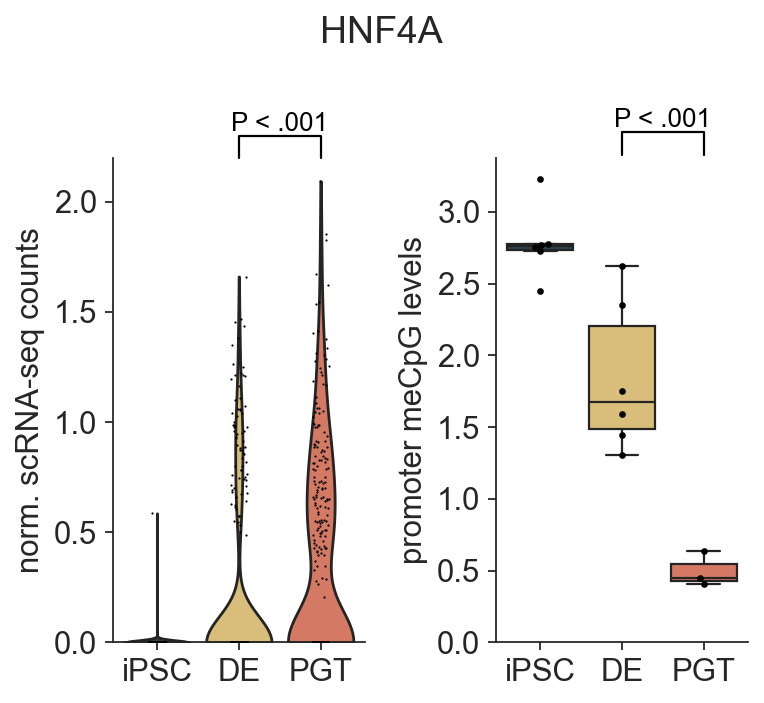

1.5102019687658043e-42 P < .001


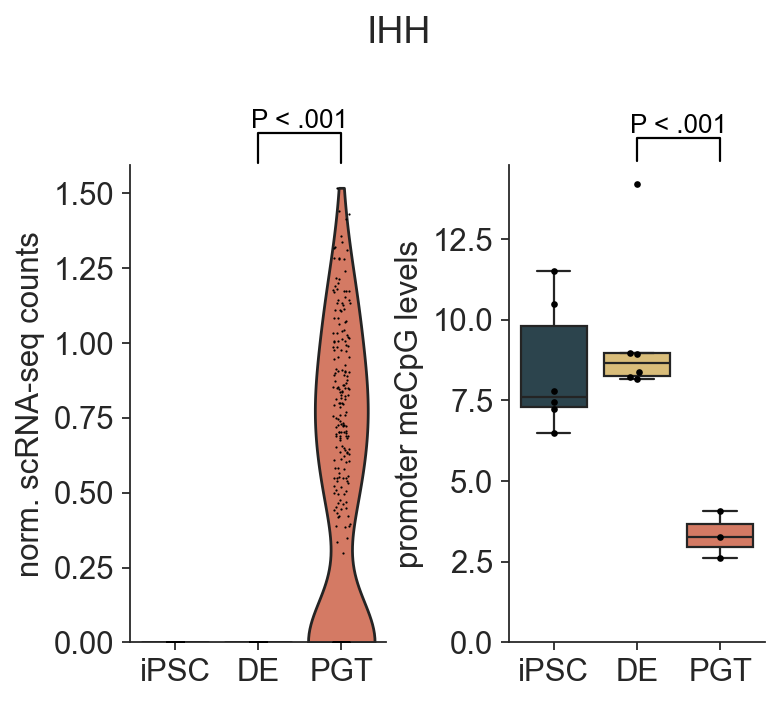

2.90640892900151e-19 P < .001


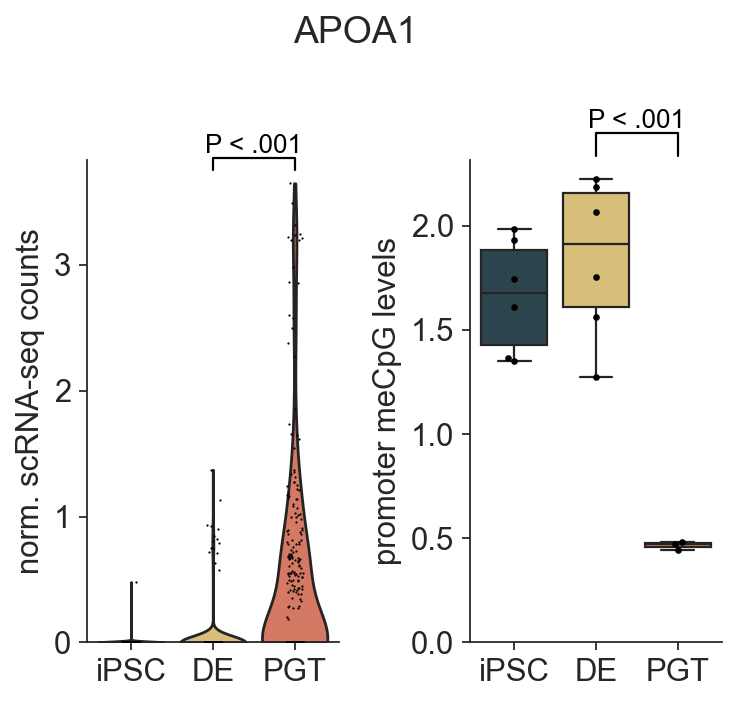

In [11]:
for gene, figurepanel in zip(["HNF4A", "IHH", "APOA1"], ["Figure5i", "SupplementalFigure7c", "SupplementalFigure7d"]): #, "IHH", "SEC16A", "PRPF4B"]:
    # Extract counts
    dmr_df = DE_PGT.copy()
    dmr_df = dmr_df[dmr_df["GeneName"] == gene]
    counts_box = counts_promoter_norm.loc[dmr_df.index]
    counts_box = counts_box.melt()
    counts_box["Celltype"] = np.where(counts_box["variable"].str.contains("DE"), "DE", 
                                      np.where(counts_box["variable"].str.contains("PGT"), "PGT", "iPSC"))

    # Plot
    fig, axs = plt.subplots(1, 2, figsize=(5, 4.5))
    sc.pl.violin(adata, gene, groupby="Celltype", show=False, ax=axs[0])
    sns.boxplot(x="Celltype", y="value", data=counts_box, ax=axs[1], palette=palette, showfliers=False)
    sns.swarmplot(x="Celltype", y="value", data=counts_box, ax=axs[1], color="black", s=3)

    # Adjust axes
    axs[0].set(xlabel="", ylabel="norm. scRNA-seq counts", ylim=(0, None))
    axs[1].set(xlabel="", ylabel="promoter meCpG levels", ylim=(0, None))
    fig.suptitle(gene)

    # Add p-values
    p_value = deg_pgt.loc[gene.split("-")[0], "pvals_adj"]
    formatted_p = f"P < .001" if p_value < 0.001 else "n.s." if p_value >= 0.05 else f"P = {p_value:.3f}"
    print(p_value, formatted_p)

    scmax = 2.2 if gene == "HNF4A" else (3.75 if gene == "APOA1" else 1.6)
    for axis, y1, y2, x1, x2, label in [[axs[0], scmax, scmax+0.1, 1, 2, formatted_p], 
                                        [axs[1], counts_box["value"].max() * 1.05, counts_box["value"].max() * 1.1, 1, 2, "P < .001"]]:
        axis.plot([x1, x1, x2, x2], [y1, y2, y2, y1], color="black", linewidth=1, clip_on=False)
        axis.text((x1+x2)/2, y2, label, ha="center", va="bottom", color="black", fontsize="small")
    
    sns.despine()
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{figurepanel}.svg", format="svg")
    plt.show()

## Figure 5f. Promoter hypomethylation

In [12]:
# Get correction factors
stats = pd.read_csv("../GEO_data/GSE304236_MeD-seq.statistics.txt", sep="\t", header=0, index_col=0)
display(stats)

,Experiment,Condition,Sample,Total reads,DCM reads,CpG reads,Total million,DCM million,CpG million,DCM/CpG ratio,Genic DCM level,Correction factor
C4neg-1,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep1,42414674,1756919,40657755,42.414674,1.756919,40.657755,0.043212,0.000347,42.414674
C4neg-2,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep2,32645592,1431276,31214316,32.645592,1.431276,31.214316,0.045853,0.000328,32.645592
C4neg-3,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep3,34929672,1383492,33546180,34.929672,1.383492,33.546180,0.041241,0.000301,34.929672
C4-1,iPSC clones,iPSC C4 +dox,iPSCs +dox C4 rep1,42715841,26629059,16086782,42.715841,26.629059,16.086782,1.655338,0.004367,55.308220
C4-2,iPSC clones,iPSC C4 +dox,iPSCs +dox C4 rep2,48475994,20953967,27522027,48.475994,20.953967,27.522027,0.761353,0.003014,43.324689
C4-3,iPSC clones,iPSC C4 +dox,iPSCs +dox C4 rep3,44165595,17234310,26931285,44.165595,17.234310,26.931285,0.639936,0.002737,35.839097
C6neg-1,iPSC clones,iPSC C6 -dox,iPSCs -dox C6 rep1,36506398,1591859,34914539,36.506398,1.591859,34.914539,0.045593,0.000351,36.506398
C6neg-2,iPSC clones,iPSC C6 -dox,iPSCs -dox C6 rep2,34477290,1273347,33203943,34.477290,1.273347,33.203943,0.038349,0.000286,34.477290
C6neg-3,iPSC clones,iPSC C6 -dox,iPSCs -dox C6 rep3,34594914,1483964,33110950,34.594914,1.483964,33.110950,0.044818,0.000322,34.594914
C6-1,iPSC clones,iPSC C6 +dox,iPSCs +dox C6 rep1,38526918,16985836,21541082,38.526918,16.985836,21.541082,0.788532,0.003195,36.500221


In [13]:
counts_gene = pd.read_csv("../NewGEOfiles/CpG_homer.txt", sep="\t", index_col=0)
counts_gene = counts_gene[counts_gene["NrSites"] > 10]

counts_promoter = counts_gene[counts_gene["Region"] == "Promoter"]
counts_promoter = counts_promoter.drop(["NrSites", "GeneName", "GeneID", "Region"], axis=1)

for sample in counts_promoter.columns:
    if sample in stats.index:
        correction = stats.loc[sample, "CpG million"]
        counts_promoter[sample] = counts_promoter[sample] / correction

counts_promoter["iPSC"] = counts_promoter[["C4neg-1", "C4neg-2", "C4neg-3", "C4-1", "C4-2", "C4-3"]].mean(axis=1)
counts_promoter["DE"] = counts_promoter[["DE-c1", "DE-c2", "DE-c3", "DE-d1", "DE-d2", "DE-d3"]].mean(axis=1)
counts_promoter["PGT"] = counts_promoter[["PGT-c1", "PGT-c2", "PGT-c3"]].mean(axis=1)
display(counts_promoter)

,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3,DE-c1,DE-c2,DE-c3,DE-d1,DE-d2,DE-d3,PGT-c1,PGT-c2,PGT-c3,iPSC,DE,PGT
Promoter.ENSG00000000003,0.000000,0.128146,0.059619,0.248651,0.109004,0.037132,0.137855,0.122556,0.219434,0.349971,0.342318,0.124091,0.272666,0.128112,0.404480,0.097092,0.216038,0.268420
Promoter.ENSG00000000460,0.000000,0.128146,0.178858,0.124326,0.072669,0.148526,0.137855,0.000000,0.156739,0.000000,0.299529,0.124091,0.000000,0.000000,0.033707,0.108754,0.119702,0.011236
Promoter.ENSG00000000971,0.172169,0.032037,0.059619,0.000000,0.000000,0.408447,0.310174,0.214474,0.188086,0.306224,0.085580,0.206819,0.170416,0.192168,0.033707,0.112045,0.218559,0.132097
Promoter.ENSG00000001167,0.418124,0.448512,0.268287,0.435140,0.545018,0.742631,0.723739,0.459587,1.097170,1.049912,1.155325,0.330911,1.533747,1.985738,1.651628,0.476285,0.802774,1.723705
Promoter.ENSG00000001460,2.361173,3.107548,1.907818,2.237862,2.616086,3.304707,3.032810,3.125190,2.664556,3.543454,2.781337,3.888200,2.385829,3.651196,3.202136,2.589199,3.172591,3.079720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Promoter.ENSG00000291258,4.968302,2.819219,4.024303,6.527098,3.415446,3.564628,4.376896,4.473311,4.137899,3.937171,5.049197,3.433197,7.532403,6.437635,5.123418,4.219833,4.234612,6.364485
Promoter.ENSG00000291259,1.893858,1.281463,1.490483,2.983816,1.889396,1.299604,1.826579,2.297934,2.821295,2.799766,3.038076,1.820008,2.965245,2.882523,3.168429,1.806437,2.433943,3.005399
Promoter.ENSG00000291270,5.878337,2.627000,2.802107,5.656818,3.488115,2.413550,3.963331,3.431581,3.667683,2.581034,5.049197,3.019559,5.828240,5.733018,5.494191,3.810988,3.618731,5.685150
Promoter.ENSG00000291280,11.633697,7.240268,7.631271,15.043406,7.920928,6.163835,12.027848,11.765421,9.467010,10.017913,11.938354,10.216865,13.326560,10.184915,11.864757,9.272234,10.905569,11.792077


/home/beatrice/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


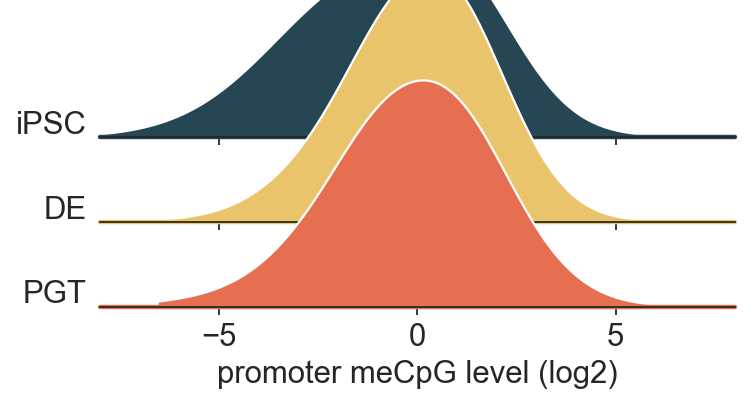

In [14]:
counts_promoter_melt = counts_promoter[["iPSC", "DE", "PGT"]].melt(var_name="condition", value_name="CpG score")
counts_promoter_melt["CpG score"] = np.log2(counts_promoter_melt["CpG score"])

g = sns.FacetGrid(counts_promoter_melt, row="condition", hue="condition", aspect=5, height=1, palette=[palette["iPSC"], palette["DE"], palette["PGT"]])
g.map(sns.kdeplot, "CpG score", cut=0, bw_adjust=3, clip_on=False, fill=True, alpha=1, linewidth=1, edgecolor="white")

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

for ax in g.axes.flat:
    ax.set_ylim(0, 0.1)
g.figure.subplots_adjust(hspace=-0.3)
for ax in g.axes.flat:
    ax.set_facecolor("none")
g.set_titles("")
g.set(yticks=[], ylabel="", xlabel="promoter meCpG level (log2)", xlim=(-8,8))
g.despine(bottom=False, left=True)

# Add labels
for ax, label in zip(g.axes.flat, counts_promoter_melt["condition"].unique()):
    ax.text(-0.02, 0.1, label, ha="right", va="center", transform=ax.transAxes)

plt.savefig(f"{output_dir}/Figure5f.svg", format="svg", bbox_inches="tight")
plt.show()

In [15]:
# Statistics
results = {}
for ct1, ct2 in combinations(["iPSC", "DE", "PGT"], 2):
    stat, p = scipy.stats.wilcoxon(counts_promoter[ct1], counts_promoter[ct2], alternative="two-sided", nan_policy="omit")
    fc = counts_promoter[ct1] - counts_promoter[ct2]
    results[f"{ct1}_{ct2}"] = {"stat": stat, "FC": np.mean(fc), "pval": p}
    
results_df = pd.DataFrame(results).T
results_df["padj"] = multipletests(results_df["pval"], method="bonferroni")[1]
print(results_df)

                stat        FC          pval          padj
iPSC_DE   15087205.0 -0.337773  0.000000e+00  0.000000e+00
iPSC_PGT  18589495.0 -0.620922  0.000000e+00  0.000000e+00
DE_PGT    45491586.0 -0.283149  9.589251e-09  2.876775e-08
